In [2]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
import numpy as np
import pandas as pd
import scipy.linalg
import plotly
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import e3nn
from e3nn import o3, io
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import compress
from itertools import product
from pymatgen.core import Structure
from pymatgen.core import Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import torch
#torch.set_default_dtype(torch.float64)
import random
import torch
import e3nn_jax

In [3]:
import sys
sys.path.append("..")
from utilities import gen_system_lattice, struct_from_lat

In [4]:
# Fixed a_value for all systems
a_value = 3

systems = [
    "cubic", "tetragonal", "orthorhombic",
    "hexagonal", "rhombohedral", "monoclinic", "triclinic"
]
seed = 42
results = {}
for sys in systems:
    results[sys] = gen_system_lattice(sys, a_value,seed=seed)

# Example printout
print(f"Using a = {a_value:.3f} Å for all systems\n")
for name, (lat, params) in results.items():
    print(f"{name}: {params}")

Using a = 3.000 Å for all systems

cubic: [3]
tetragonal: [3, 3.162464172120849]
orthorhombic: [3, 3.162464172120849, 4.117272068519359]
hexagonal: [3, 3.162464172120849]
rhombohedral: [3, 57.92003178751901]
monoclinic: [3, 3.162464172120849, 4.117272068519359, 91.52358539877216]
triclinic: [3, 3.162464172120849, 4.117272068519359, 95.92104087178092, 77.82532043662948, 104.26867054910268]


In [34]:
radial_function = "bessel"
n_basis = 10
lmax = 6
sph = io.SphericalTensor(lmax, 1, -1)

In [35]:
import e3nn_jax as e3nn_jax
rtp_bi = e3nn_jax.reduced_symmetric_tensor_product_basis(sph, 3, keep_ir=['0o', '0e'])
cob_bi = torch.tensor(rtp_bi.array,dtype=torch.float64)

In [21]:
# get labeled components of irreps
rtp1 = e3nn.o3.ReducedTensorProducts('ijk=kij=jki=ikj', i=sph, filter_ir_out=["0e","0o"])
ftp = e3nn.o3.FullTensorProduct(irreps_in1=rtp1.irreps_out, irreps_in2=sph,filter_ir_out=["0e","0o"])

In [23]:
from e3nn.o3 import Irreps
from collections import defaultdict

C = rtp1.change_of_basis  # shape (dim_out, dim_i, dim_j, dim_k)
irreps_out = rtp1.irreps_out
irreps_in = sph
threshold = 1e-6

# Dynamically get slices for all input irreps
irreps_slices = list(zip(irreps_in, irreps_in.slices()))

def component_to_irrep(idx):
    """Map a component index to its corresponding input irrep."""
    for ir, s in irreps_slices:
        if idx in range(s.start, s.stop):
            return ir
    raise ValueError(f"Index {idx} not found in any input irrep slice")

# Collect contributions
all_contributions = []

for out_idx in range(C.shape[0]):
    unique_contributions = set()
    
    # Find all non-negligible entries in the tensor
    inds = (C[out_idx].abs() > threshold).nonzero(as_tuple=False)
    
    for idx_i, idx_j, idx_k in inds:
        # Map each component to its irrep
        ir_i = component_to_irrep(idx_i.item())
        ir_j = component_to_irrep(idx_j.item())
        ir_k = component_to_irrep(idx_k.item())
        
        # Store the irrep triple
        unique_contributions.add((ir_i, ir_j, ir_k))
    
    # Add to list for all output components
    all_contributions.append(unique_contributions)

print("Example contributions for first output component:", all_contributions[0])


Example contributions for first output component: {(1x0e, 1x0e, 1x0e)}


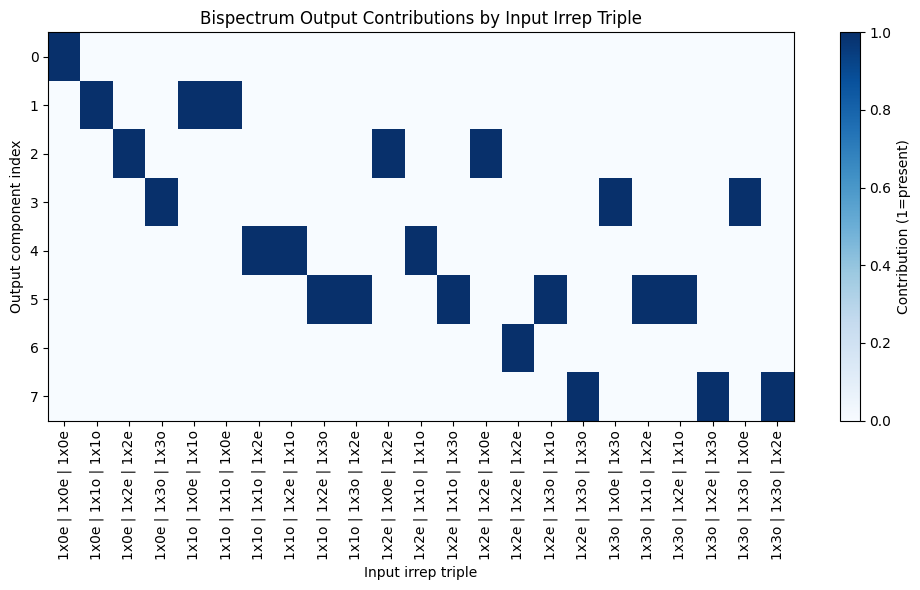

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten each set of triples into strings for labeling
all_triples = []
for s in all_contributions:
    for triple in s:
        triple_str = " | ".join(str(ir) for ir in triple)  # convert each irrep to string
        all_triples.append(triple_str)

all_triples = sorted(list(set(all_triples)))  # unique triple types

# Build a binary matrix: rows=output components, cols=triple types
matrix = np.zeros((len(all_contributions), len(all_triples)))

for i, s in enumerate(all_contributions):
    for triple in s:
        triple_str = " | ".join(str(ir) for ir in triple)
        col_idx = all_triples.index(triple_str)
        matrix[i, col_idx] = 1  # mark presence


# Plot heatmap
plt.figure(figsize=(10,6))
plt.imshow(matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Contribution (1=present)")
plt.xlabel("Input irrep triple")
plt.ylabel("Output component index")
plt.xticks(ticks=np.arange(len(all_triples)), labels=all_triples, rotation=90)
plt.yticks(ticks=np.arange(len(all_contributions)), labels=np.arange(len(all_contributions)))
plt.title("Bispectrum Output Contributions by Input Irrep Triple")
plt.tight_layout()
plt.show()
##TODO: try to visualize bispectrum better/components?

In [36]:
def get_bispectrum(vec,k_max,lmax,radial_function,n_basis,cob_bi):
    bases = ["bessel","gaussian", "cosine", "smooth_finite", "fourier","none"]
    assert radial_function in bases, "Invalid basis function"
    #res = torch.zeros(vec.shape[0],n_basis,(sph.lmax+1)**2)
    # get spherical harmonics
    sph_harm = o3.spherical_harmonics(range(0,lmax+1),vec,normalize="False")
    radii = torch.linalg.norm(vec,axis=-1)
    basis = e3nn.math.soft_one_hot_linspace(radii,0,k_max,number=n_basis,basis=radial_function,cutoff=False)
    # Add a new dimension to the tensors
    sph_harm = sph_harm.unsqueeze(1)  # shape: (136, 10, 1)
    basis = basis.unsqueeze(2)  # shape: (136, 1, 49)
    combined_tensor = torch.matmul(basis,sph_harm)
    radial_proj = torch.sum(combined_tensor,axis=0)
    bispec = torch.einsum("...i,...j,...k,ijkz->...z",radial_proj,radial_proj,radial_proj,cob_bi)
    return bispec

In [37]:
from utilities import struct_from_lat

In [38]:
import ase
bispecs = {}
structs = {}
lmax=6
from matscipy.neighbours import neighbour_list
for lat_type, lat in results.items():
    k_max = 2/3
    struct = struct_from_lat(lat[0])
    structs[lat_type] = struct
    lat = struct.get_primitive_structure().lattice
    recip_lat = lat.reciprocal_lattice_crystallographic
    recip = ase.Atoms(symbols = ['C'],positions = np.array([[0.0,0.0,0.0]]),cell=recip_lat.matrix,pbc=True)
    # neighbor list gives atomic distanes and miller indices
    neighs_dist,neighs_miller = neighbour_list('dS',recip,cutoff=k_max)
    print(neighs_miller)
    # get the atomic positions
    neighs_dist = np.asarray(neighs_dist)
    neighs_miller = np.asarray(neighs_miller)
    neighs = torch.tensor(neighs_miller.reshape(-1,3)@recip_lat.matrix)
    bispec = get_bispectrum(neighs,k_max,lmax,radial_function,n_basis,cob_bi)
    bispecs[lat_type] = bispec

[[-1 -1 -1]
 [ 0 -1 -1]
 [ 1 -1 -1]
 [-1  0 -1]
 [ 0  0 -1]
 [ 1  0 -1]
 [-1  1 -1]
 [ 0  1 -1]
 [ 1  1 -1]
 [-1 -1  0]
 [ 0 -1  0]
 [ 1 -1  0]
 [-1  0  0]
 [ 1  0  0]
 [-1  1  0]
 [ 0  1  0]
 [ 1  1  0]
 [-1 -1  1]
 [ 0 -1  1]
 [ 1 -1  1]
 [-1  0  1]
 [ 0  0  1]
 [ 1  0  1]
 [-1  1  1]
 [ 0  1  1]
 [ 1  1  1]]
[[ 0  0 -2]
 [-1 -1 -1]
 [ 0 -1 -1]
 [ 1 -1 -1]
 [-1  0 -1]
 [ 0  0 -1]
 [ 1  0 -1]
 [-1  1 -1]
 [ 0  1 -1]
 [ 1  1 -1]
 [-1 -1  0]
 [ 0 -1  0]
 [ 1 -1  0]
 [-1  0  0]
 [ 1  0  0]
 [-1  1  0]
 [ 0  1  0]
 [ 1  1  0]
 [-1 -1  1]
 [ 0 -1  1]
 [ 1 -1  1]
 [-1  0  1]
 [ 0  0  1]
 [ 1  0  1]
 [-1  1  1]
 [ 0  1  1]
 [ 1  1  1]
 [ 0  0  2]]
[[ 0 -1 -2]
 [-1  0 -2]
 [ 0  0 -2]
 [ 1  0 -2]
 [ 0  1 -2]
 [-1 -1 -1]
 [ 0 -1 -1]
 [ 1 -1 -1]
 [-1  0 -1]
 [ 0  0 -1]
 [ 1  0 -1]
 [-1  1 -1]
 [ 0  1 -1]
 [ 1  1 -1]
 [ 0 -2  0]
 [-1 -1  0]
 [ 0 -1  0]
 [ 1 -1  0]
 [-1  0  0]
 [ 1  0  0]
 [-1  1  0]
 [ 0  1  0]
 [ 1  1  0]
 [ 0  2  0]
 [-1 -1  1]
 [ 0 -1  1]
 [ 1 -1  1]
 [-1  0  1]
 [ 0  0  1]
 [

/Users/elyssahofgard/opt/miniconda3/envs/tda_env/lib/python3.12/site-packages/matplotlib/transforms.py:2663: RuntimeWarning: invalid value encountered in scalar multiply
  [0.0    , y_scale, (-inb*y_scale)],
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite v

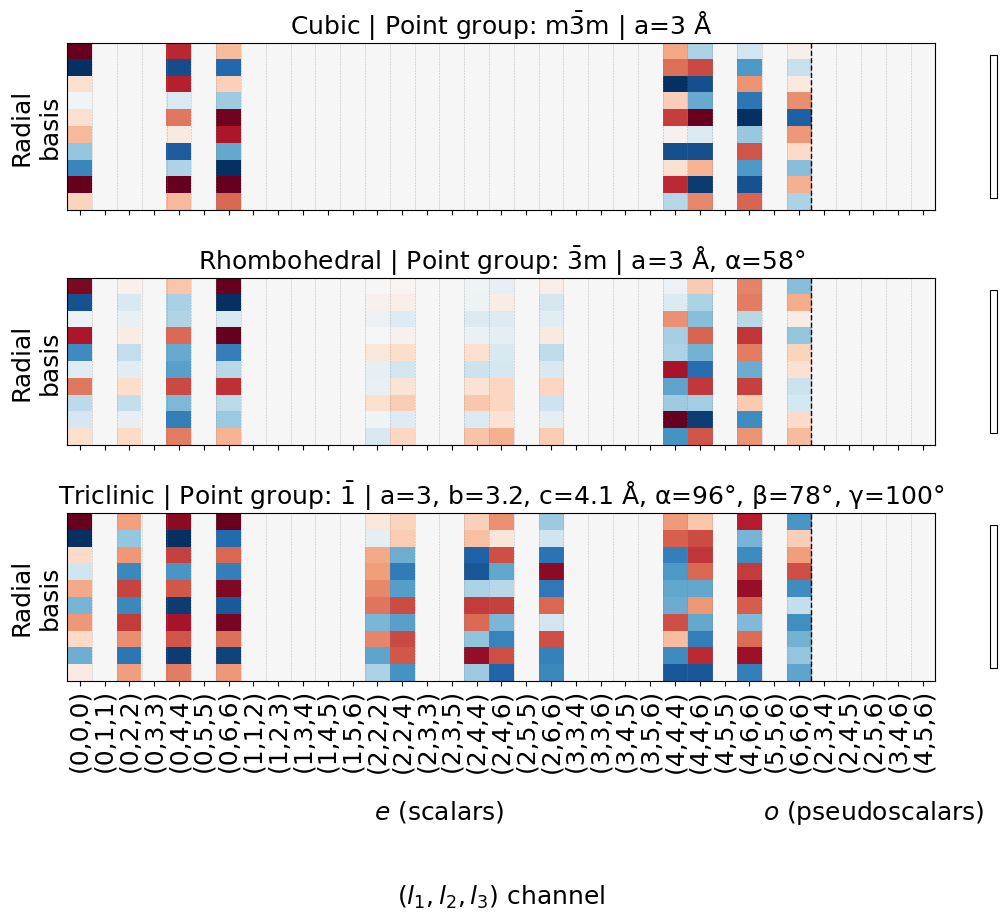

In [13]:
from matplotlib.colors import TwoSlopeNorm
import re

# compute global scale once
all_scaled = torch.cat([torch.flatten(
    torch.sign(b)*torch.abs(b).pow(1/3)
) for b in bispecs.values()])
vmax = all_scaled.abs().quantile(0.98).item()

norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
plt.rcParams['font.size'] = 18
def bar_fmt(x):
    s = f'{abs(x):.2g}'
    return r'$\bar{' + s + r'}$' if x < 0 else f'{x:.2g}'

def fmt_point_group(pg):
    return re.sub(r'-(\d)', lambda m: r'$\bar{' + m.group(1) + r'}$', pg)

def fmt2g(x):
    """2 significant figures, no scientific notation."""
    return f'{float(f"{x:.2g}"):g}'

# Build x-axis labels directly from cob_bi structure
def idx_to_l(idx):
    for l in range(lmax + 1):
        if l*l <= idx < (l+1)*(l+1):
            return l

channel_labels = []
channel_parities = []
for z in range(cob_bi.shape[-1]):
    nonzero = (cob_bi[:, :, :, z].abs() > 1e-10).nonzero(as_tuple=False)
    triples = set()
    for idx in nonzero:
        ls = tuple(sorted([idx_to_l(idx[0].item()),
                           idx_to_l(idx[1].item()),
                           idx_to_l(idx[2].item())]))
        triples.add(ls)
    assert len(triples) == 1, f"Channel {z} mixes multiple l-triples: {triples}"
    ls = triples.pop()
    parity = 'e' if sum(ls) % 2 == 0 else 'o'
    channel_parities.append(parity)
    channel_labels.append(f"({ls[0]},{ls[1]},{ls[2]})")

n_channels = len(channel_labels)
first_odd = next((i for i, p in enumerate(channel_parities) if p == 'o'), None)

def lat_param_str(lat_type, l):
    a, b, c = l.a, l.b, l.c
    al, be, ga = l.alpha, l.beta, l.gamma
    if lat_type == 'cubic':
        return f"a={fmt2g(a)} Å"
    elif lat_type == 'rhombohedral':
        return f"a={fmt2g(a)} Å, α={fmt2g(al)}°"
    elif lat_type == 'triclinic':
        return f"a={fmt2g(a)}, b={fmt2g(b)}, c={fmt2g(c)} Å, α={fmt2g(al)}°, β={fmt2g(be)}°, γ={fmt2g(ga)}°"

plot_systems = ['cubic', 'rhombohedral', 'triclinic']

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax, lat_type in zip(axes, plot_systems):
    bispec = bispecs[lat_type]
    scaled = torch.sign(bispec) * torch.abs(bispec).pow(1/3)

    struct = structs[lat_type]
    sga = SpacegroupAnalyzer(struct, symprec=1e-2)
    pg = fmt_point_group(sga.get_point_group_symbol())
    lat_str = lat_param_str(lat_type, struct.lattice)

    im = ax.imshow(scaled, cmap="RdBu_r", norm=norm, aspect="auto")
    ax.set_ylabel("Radial\nbasis", fontsize=18)
    ax.set_yticks([])
    ax.set_title(f"{lat_type.capitalize()} | Point group: {pg} | {lat_str}", fontsize=18)

    for x in np.arange(n_channels) - 0.5:
        ax.axvline(x=x, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)

    if first_odd is not None:
        ax.axvline(x=first_odd - 0.5, color='k', linestyle='--', linewidth=1)

    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    ticks = cb.get_ticks()
    cb.set_ticks(ticks)
    cb.set_ticklabels([bar_fmt(t) for t in ticks])

# only label x-axis on bottom panel
axes[-1].set_xticks(np.arange(n_channels))
axes[-1].set_xticklabels(channel_labels, fontsize=18, rotation=90, ha='center')
axes[-1].xaxis.set_tick_params(which='both', labelbottom=True, pad=2)
axes[-1].set_xlabel(r"$(l_1, l_2, l_3)$ channel", fontsize=18, labelpad=80)

if first_odd is not None:
    axes[-1].text(first_odd * 0.5 - 0.5, -0.7, r'$e$ (scalars)', ha='center', va='top',
                  fontsize=18, transform=axes[-1].get_xaxis_transform())
    axes[-1].text(first_odd + (n_channels - first_odd) * 0.5 - 0.5, -0.7, r'$o$ (pseudoscalars)',
                  ha='center', va='top', fontsize=18, transform=axes[-1].get_xaxis_transform())

plt.subplots_adjust(bottom=0.3, hspace=0.4)
plt.savefig("bispec_lat_type.pdf", bbox_inches='tight')
plt.show()